# GO Price Data

This notebook analyses Argus-assessed midpoint prices for European Guarantee of Origin contracts. Each observation is characterised by:
- **Code** $k \in \mathcal{K}$: the contract specification (technology and geography).
- **Date** $t$: the assessment date.
- **Production year** $y$: the vintage year of the underlying electricity production.
- **Value** $P_k(t, y)$: the assessed midpoint price in €/MWh.

The dataset covers four contract types $\mathcal{K} = \{\text{Wind EU},\; \text{Solar EU},\; \text{Hydro Nordic},\; \text{Any Renewable EU}\}$ with production years spanning 2019–2030.

## Imports

Load required libraries and the database query interface.

In [15]:
from functions.sql_data import get_sql_query
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Parameters

Define the contract set $\mathcal{K}$, minimum production year for filtering, and short labels for visualization.

In [16]:
# Contract codes to retrieve from pub.Argus_Certificate_Price
GO_CONTRACT_CODES = [
    'Guarantee of origin wind Europe year',
    'Guarantee of origin Solar Europe year',
    'Guarantee of origin hydro Nordic year',
    'Guarantee of origin any renewable Europe year',
]

# Minimum production year (ForwardPeriodValue) to include
MIN_PRODUCTION_YEAR = 2020

# Production years to show in cross-contract comparison panels
COMPARISON_YEARS = [2024, 2025, 2026, 2027]

# Short labels for plotting
CODE_LABELS = {
    'Guarantee of origin any renewable Europe year': 'Any Renewable EU',
    'Guarantee of origin hydro Nordic year': 'Hydro Nordic',
    'Guarantee of origin Solar Europe year': 'Solar EU',
    'Guarantee of origin wind Europe year': 'Wind EU',
}

## Data Collection

Retrieve Argus midpoint price assessments $P_k(t, y)$ for each contract $k \in \mathcal{K}$ with production year $y \geq$ `MIN_PRODUCTION_YEAR`.

In [17]:
codes_sql = ", ".join(f"'{c}'" for c in GO_CONTRACT_CODES)

go_price_query = f'''
SELECT Code, [Date], ForwardPeriodValue, [Value]
FROM pub.Argus_Certificate_Price
WHERE PriceType = 'Midpoint'
AND CODE IN ({codes_sql})
AND ForwardPeriodValue >= {MIN_PRODUCTION_YEAR}
ORDER BY [Date] DESC, ForwardPeriodValue ASC
'''

go_price_df = get_sql_query(go_price_query)

display(go_price_df)

,Code,Date,ForwardPeriodValue,Value
0,Guarantee of origin any renewable Europe year,2026-06-05,2025,1.530
1,Guarantee of origin hydro Nordic year,2026-06-05,2025,1.560
2,Guarantee of origin Solar Europe year,2026-06-05,2025,1.560
3,Guarantee of origin wind Europe year,2026-06-05,2025,1.560
4,Guarantee of origin wind Europe year,2026-06-05,2026,1.840
...,...,...,...,...
31585,Guarantee of origin hydro Nordic year,2019-11-13,2020,0.515
31586,Guarantee of origin hydro Nordic year,2019-11-12,2020,0.515
31587,Guarantee of origin wind Europe year,2019-11-12,2020,0.600
31588,Guarantee of origin wind Europe year,2019-11-11,2020,0.605


In [18]:
go_price_df['Date'] = pd.to_datetime(go_price_df['Date'])
go_price_df['ForwardPeriodValue'] = go_price_df['ForwardPeriodValue'].astype(int)
go_price_df['code_short'] = go_price_df['Code'].map(CODE_LABELS)
go_price_df = go_price_df.sort_values('Date').reset_index(drop=True)

## Price Term Structure by Contract Type

For each contract $k$, we plot the price $P_k(t, y)$ as a function of assessment date $t$, with one curve per production year $y$. This reveals the **term structure** — how the market prices production vintages of varying proximity — and highlights the 2022–2023 price spike driven by the European energy crisis.

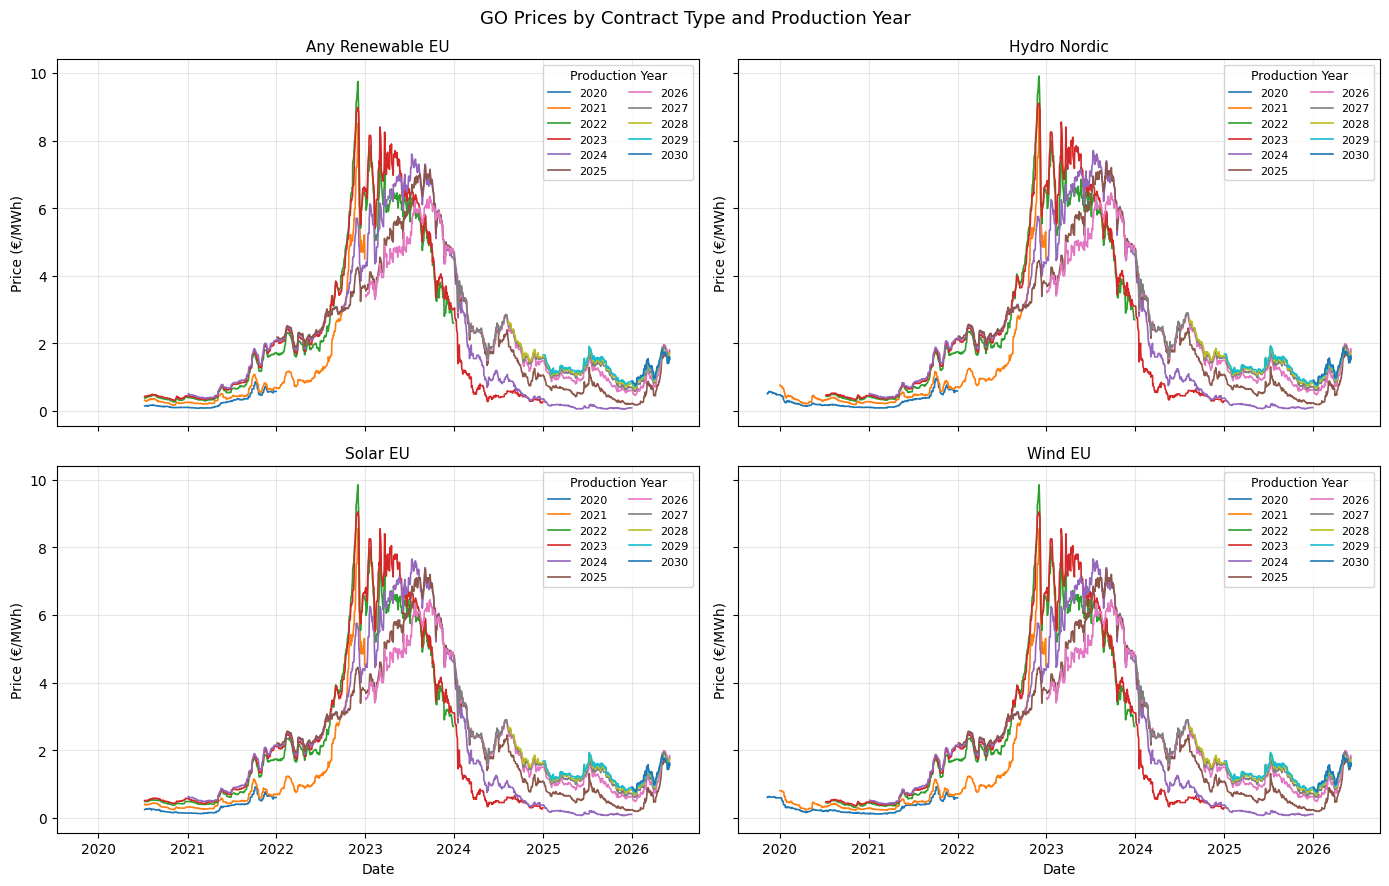

In [19]:
# Price evolution by production year — one panel per Code
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, (code, label) in enumerate(CODE_LABELS.items()):
    ax = axes[i]
    subset = go_price_df[go_price_df['Code'] == code]
    for year, grp in subset.groupby('ForwardPeriodValue'):
        ax.plot(grp['Date'], grp['Value'], linewidth=1.2, label=str(year))
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Price (€/MWh)')
    ax.legend(title='Production Year', fontsize=8, title_fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Date')
axes[3].set_xlabel('Date')
fig.suptitle('GO Prices by Contract Type and Production Year', fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

## Cross-Contract Comparison by Production Year

Fixing the production year $y$ and plotting all contracts $k \in \mathcal{K}$ on a common axis isolates the **technology premium** — the price differential attributable to the specific energy source. For a given $y$:

$$\Delta_k(t, y) = P_k(t, y) - P_{\text{any}}(t, y)$$

where $P_{\text{any}}$ is the "Any Renewable EU" benchmark. The following panels show all contract types for production years 2024–2027.

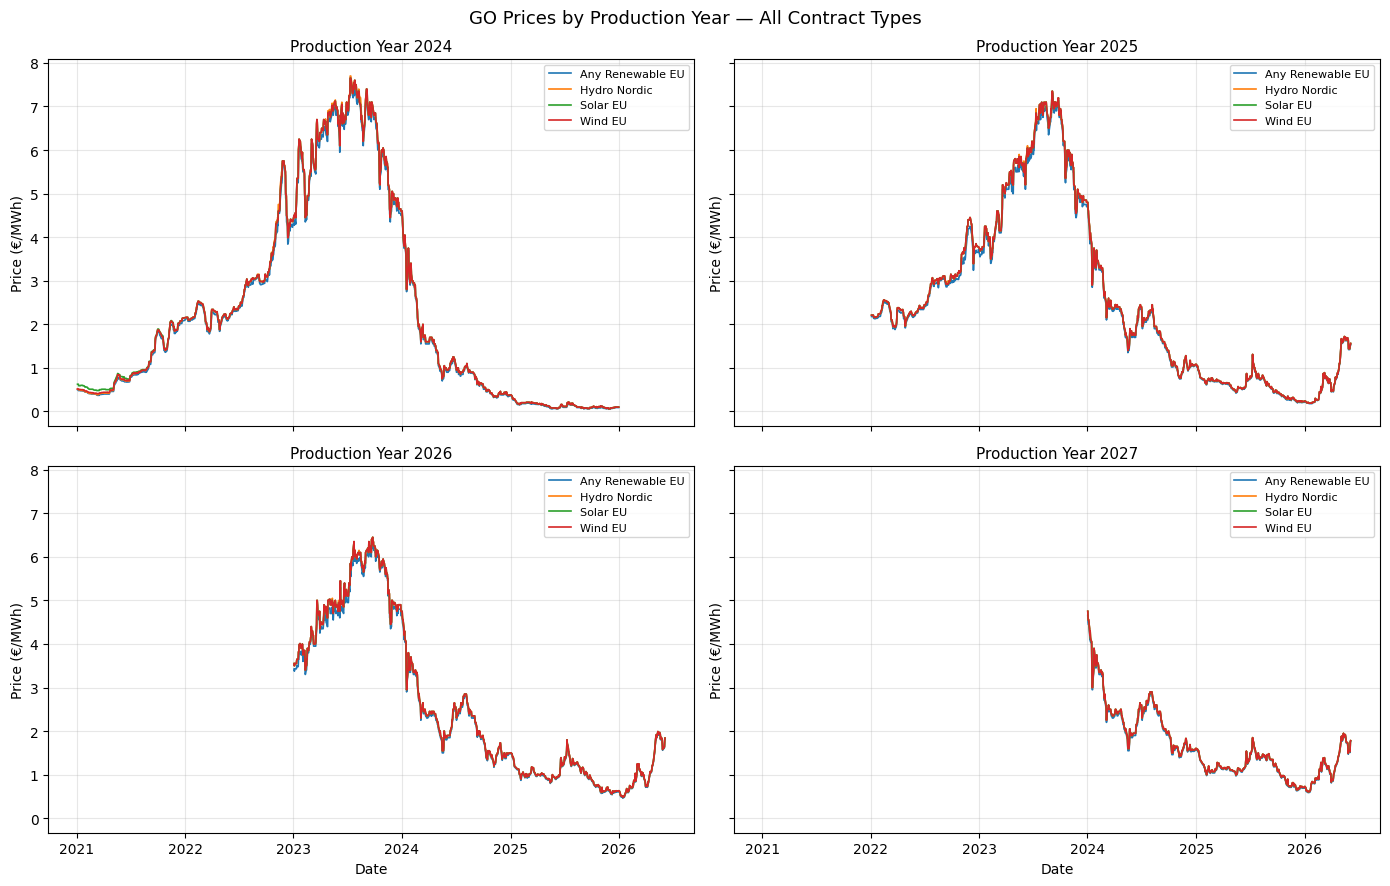

In [20]:
# Price evolution by Code — one panel per production year
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, year in enumerate(COMPARISON_YEARS):
    ax = axes[i]
    subset = go_price_df[go_price_df['ForwardPeriodValue'] == year].sort_values('Date')
    for code, grp in subset.groupby('code_short'):
        ax.plot(grp['Date'].values, grp['Value'].values, linewidth=1.2, label=code)
    ax.set_title(f'Production Year {year}', fontsize=11)
    ax.set_ylabel('Price (€/MWh)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Date')
axes[3].set_xlabel('Date')
fig.suptitle('GO Prices by Production Year — All Contract Types', fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

## Technology Premium

The spread $\Delta_k(t, y) = P_k(t, y) - P_{\text{any}}(t, y)$ quantifies the marginal willingness-to-pay for a specific technology label relative to an undifferentiated renewable GO. A persistent $\Delta_k > 0$ indicates the market assigns additional value to that technology's provenance (e.g., additionality perception, corporate preference). Convergence toward zero signals commoditisation across renewable types.

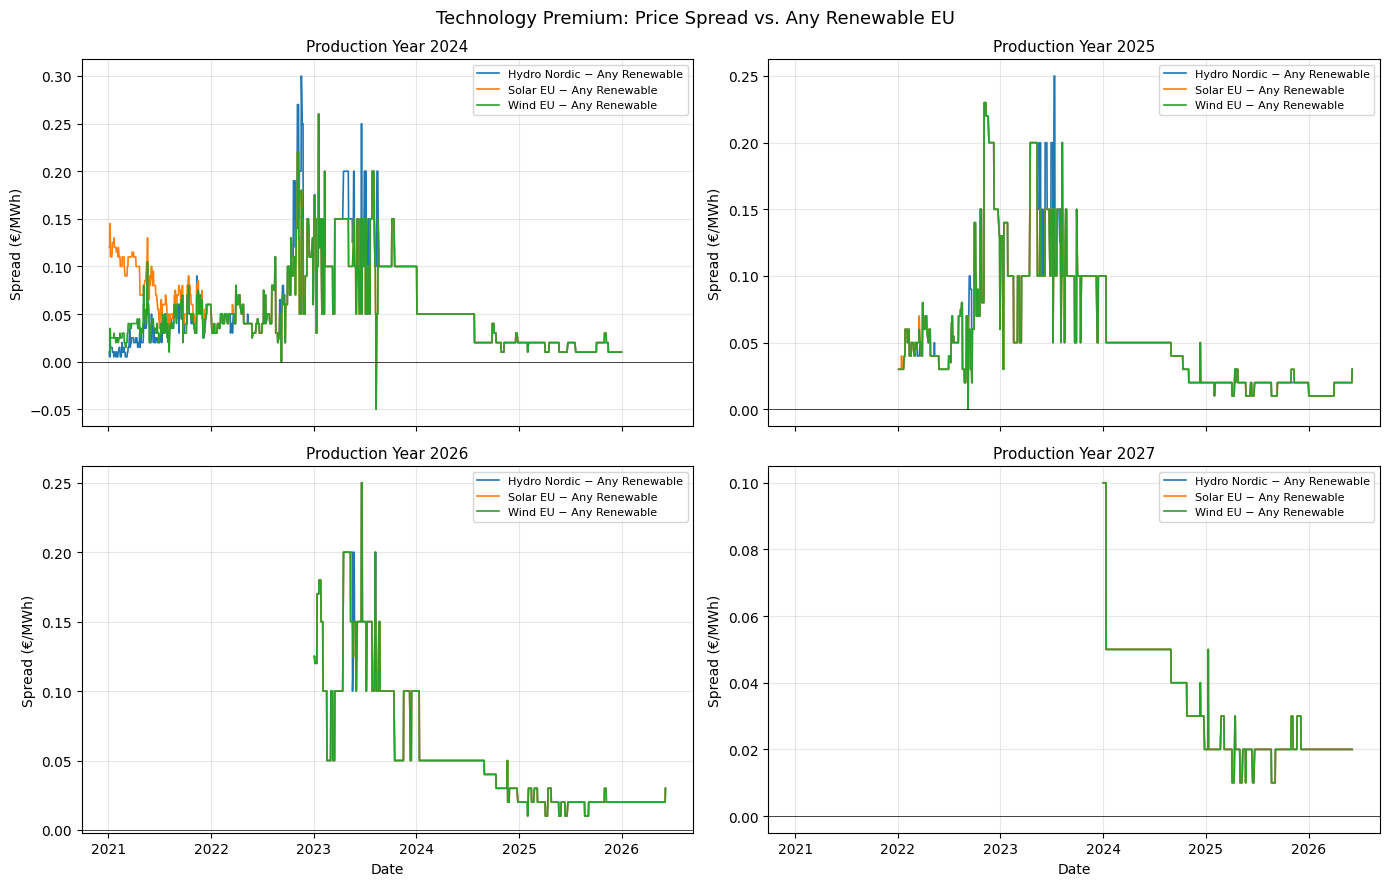

In [ ]:
# Spread between contract types vs. "Any Renewable" baseline (same production year)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for i, year in enumerate(COMPARISON_YEARS):
    ax = axes[i]
    subset = go_price_df[go_price_df['ForwardPeriodValue'] == year].pivot_table(
        index='Date', columns='code_short', values='Value', aggfunc='first')
    subset = subset.sort_index()
    if 'Any Renewable EU' in subset.columns:
        for col in subset.columns:
            if col != 'Any Renewable EU':
                spread = subset[col] - subset['Any Renewable EU']
                spread = spread.dropna()
                ax.plot(spread.index, spread.values, linewidth=1.2, label=f'{col} − Any Renewable')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'Production Year {year}', fontsize=11)
    ax.set_ylabel('Spread (€/MWh)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Date')
axes[3].set_xlabel('Date')
fig.suptitle('Technology Premium: Price Spread vs. Any Renewable EU', fontsize=13, y=0.98)
plt.tight_layout()
plt.show()